In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set()

# Paleta del curso
AZUL = "#007aff"
MAGENTA = "#ff48fd"
VERDE = "#44c57f"
NARANJA = "#ffa600"
CELESTE = "#8ecae6"
GRIS = "#555555"

# Calibración de modelos
**Aprendizaje de Máquina - CEIA - FIUBA**

Hasta ahora, cada vez que evaluamos un clasificador nos preguntamos lo mismo: **¿acierta?**. Accuracy, matriz de
confusión, AUC-ROC. Todas responden a esa pregunta.

En esta notebook nos hacemos otra, que ninguna de esas métricas responde: cuando el modelo devuelve `0.7`,
**¿ese número significa algo?** ¿De cada 100 casos con ese score, efectivamente 70 son positivos?

La respuesta importa cada vez que la probabilidad no se usa solo para elegir una clase, sino que entra en un
cálculo: un valor esperado, una matriz de costos, una priorización.

Vamos a usar el [módulo de calibración de Scikit-learn](https://scikit-learn.org/stable/modules/calibration.html).

## Los datos

Usamos el dataset [UCI_Credit_Card](https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset).
Contiene el historial de **30.000 clientes de tarjeta de crédito de un banco de Taiwán** entre abril y septiembre de
2005, y la variable a predecir es si el cliente **cayó en default** (no pagó) el mes siguiente.

Es un problema donde la calibración importa de verdad: nadie decide otorgar crédito mirando solo la clase predicha,
se decide calculando el valor esperado de la operación.

> **Este dataset no lo recorrimos en clase.** Aparece en los ejercicios de las clases 3, 4 y 5, pero nunca lo
> exploramos. Si no lo conocés, o si querés ver de dónde salen las conclusiones que usamos más abajo, está la
> notebook **`EDA - UCI Credit Card`** de esta misma clase.

Las 23 features se agrupan en tres bloques:

| Bloque | Variables | Qué son |
|---|---|---|
| Perfil | `LIMIT_BAL`, `SEX`, `EDUCATION`, `MARRIAGE`, `AGE` | Límite de crédito (en NT\$) y datos demográficos |
| Historial de atrasos | `PAY_0` … `PAY_6` | Meses de atraso en cada uno de los 6 meses (`PAY_0` = septiembre) |
| Montos mensuales | `BILL_AMT1` … `BILL_AMT6`, `PAY_AMT1` … `PAY_AMT6` | Lo facturado y lo pagado cada mes, en NT\$ |

Dos cosas del EDA que van a ser importantes en esta notebook:

1. **`PAY_0` es el predictor dominante, y su relación con el default no es lineal**: la tasa salta de $12.8\%$ a
   $69.1\%$ entre estar al día y arrastrar dos meses de atraso, pero entre los valores $-2$, $-1$ y $0$ prácticamente
   no cambia.
2. **Los seis `BILL_AMT*` están fuertemente correlacionados entre sí** (correlación media de $0.89$). Son el saldo
   del mismo cliente en seis meses consecutivos: una sola señal medida seis veces.

In [2]:
df = pd.read_csv("data/UCI_Credit_Card.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
df.shape

(30000, 25)

La columna `default.payment.next.month` es el target. `ID` no aporta información, así que la descartamos.

In [4]:
X = df.drop(columns=["ID", "default.payment.next.month"])
y = df["default.payment.next.month"]

print(f"Observaciones: {X.shape[0]}, features: {X.shape[1]}")

Observaciones: 30000, features: 23


Antes de entrenar nada, miremos la **tasa base**: qué proporción de clientes cae en default. Este número va a
reaparecer varias veces.

In [5]:
tasa_base = y.mean()
print(f"Tasa base de default: {tasa_base:.4f}  ({tasa_base:.2%})")

Tasa base de default: 0.2212  (22.12%)


Un $22\%$ de default. Dos cosas se desprenden de acá:

- El dataset está **desbalanceado**, así que el accuracy va a ser engañoso: un modelo que prediga "nunca hay
  default" ya acierta el $78\%$ de las veces.
- Un modelo que no aprendiera nada, pero conociera esta tasa, predeciría $0.22$ para todos. Ese es nuestro piso de
  comparación, y lo vamos a usar más adelante.

Separamos en entrenamiento y testeo, estratificando para mantener la proporción de clases.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Tasa base en test: {y_test.mean():.4f}")

Train: 21000 | Test: 9000
Tasa base en test: 0.2212


### Preparación de las features

`pandas` lee las 23 columnas como números, pero en el EDA vimos que **no todas lo son**. Hay tres tipos y cada uno
necesita un tratamiento distinto:

| Tipo | Variables | Tratamiento |
|---|---|---|
| Categóricas nominales | `SEX`, `EDUCATION`, `MARRIAGE` | *One-hot*: los números son etiquetas sin orden |
| Categóricas ordinales | `PAY_0` … `PAY_6` | *One-hot*: tienen orden, pero su efecto es un escalón, no una recta |
| Numéricas continuas | `LIMIT_BAL`, `AGE`, `BILL_AMT*`, `PAY_AMT*` | Escalado: van de decenas a cientos de miles |

La decisión menos obvia es la de las `PAY_*`. Son ordinales, así que uno podría dejarlas como números. Pero el EDA
mostró que la tasa de default es prácticamente igual para $-2$, $-1$ y $0$, y recién salta a partir de $1$: es un
**escalón**. Si las dejamos como numéricas, obligamos a los modelos lineales a representar ese salto con una
pendiente constante, que es justamente lo que no pueden hacer. Codificarlas como categorías les da la libertad de
asignarle un coeficiente propio a cada nivel.

Antes de eso, aplicamos la limpieza que identificamos en el EDA: las categorías no documentadas van a "otros", y los
atrasos de 4 meses o más se agrupan por ser muy poco frecuentes.

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

NOMINALES = ["SEX", "EDUCATION", "MARRIAGE"]
ORDINALES = ["PAY_0"] + [f"PAY_{i}" for i in range(2, 7)]
NUMERICAS = (["LIMIT_BAL", "AGE"]
             + [f"BILL_AMT{i}" for i in range(1, 7)]
             + [f"PAY_AMT{i}" for i in range(1, 7)])


def limpiar(datos):
    """Agrupa las categorías no documentadas y los atrasos poco frecuentes."""
    datos = datos.copy()
    datos["EDUCATION"] = datos["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
    datos["MARRIAGE"] = datos["MARRIAGE"].replace({0: 3})
    for col in ORDINALES:
        datos[col] = datos[col].clip(-1, 4)
    return datos


X_train, X_test = limpiar(X_train), limpiar(X_test)


def preprocesador():
    ohe = OneHotEncoder(drop="first", handle_unknown="ignore")
    return ColumnTransformer([
        ("cat", ohe, NOMINALES + ORDINALES),
        ("num", StandardScaler(), NUMERICAS),
    ])

## Los tres modelos que vamos a usar

Para estudiar la calibración necesitamos modelos que produzcan probabilidades de maneras distintas. Vamos a usar
tres:

- **Regresión logística.** Optimiza directamente la probabilidad: minimizar *log loss* equivale a maximizar la
  verosimilitud del modelo de Bernoulli. Es el único de los tres cuyo objetivo de entrenamiento **es** producir
  buenas probabilidades.
- **Random Forest.** Su probabilidad es la fracción de árboles del ensamble que votan por la clase. Es un
  subproducto del mecanismo de votación, no algo que el modelo optimice.
- **Naive Bayes gaussiano.** Es el único de los tres que no vimos en clases anteriores, así que vale una línea:
  aplica el teorema de Bayes asumiendo que **todas las features son independientes entre sí dada la clase**, y
  modela cada una con una gaussiana. Esa hipótesis de independencia casi nunca se cumple, y es de donde salen sus
  problemas.

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline

In [9]:
def bosque():
    return RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)


lr = make_pipeline(preprocesador(), LogisticRegression(max_iter=2000, random_state=42))
rf = make_pipeline(preprocesador(), bosque())
gnb = make_pipeline(preprocesador(), GaussianNB())

for modelo in (lr, rf, gnb):
    modelo.fit(X_train, y_train)

print("Modelos entrenados")

Modelos entrenados


In [10]:
# Probabilidades de la clase positiva (default) sobre el conjunto de testeo
probs = {
    "Regresión logística": lr.predict_proba(X_test)[:, 1],
    "Random Forest": rf.predict_proba(X_test)[:, 1],
    "Naive Bayes": gnb.predict_proba(X_test)[:, 1],
}

### Primero, la discriminación

Veamos qué tan bien ordena cada modelo.

In [11]:
from sklearn.metrics import accuracy_score, roc_auc_score

pd.DataFrame({
    nombre: {
        "AUC": roc_auc_score(y_test, p),
        "Accuracy": accuracy_score(y_test, p >= 0.5),  # noqa: PLR2004
    }
    for nombre, p in probs.items()
}).T.round(4)

,AUC,Accuracy
Regresión logística,0.7628,0.8177
Random Forest,0.7627,0.8130
Naive Bayes,0.7459,0.8081


Los tres discriminan de forma parecida: los AUC van de $0.746$ a $0.763$, y el accuracy de los tres ronda el
$0.81$. Si nos quedáramos acá, concluiríamos que los tres modelos son más o menos intercambiables —y que ninguno es
gran cosa, porque el baseline por tabla del EDA ya conseguía un accuracy de $0.818$—.

### Ahora, las probabilidades

Miremos qué números están produciendo realmente.

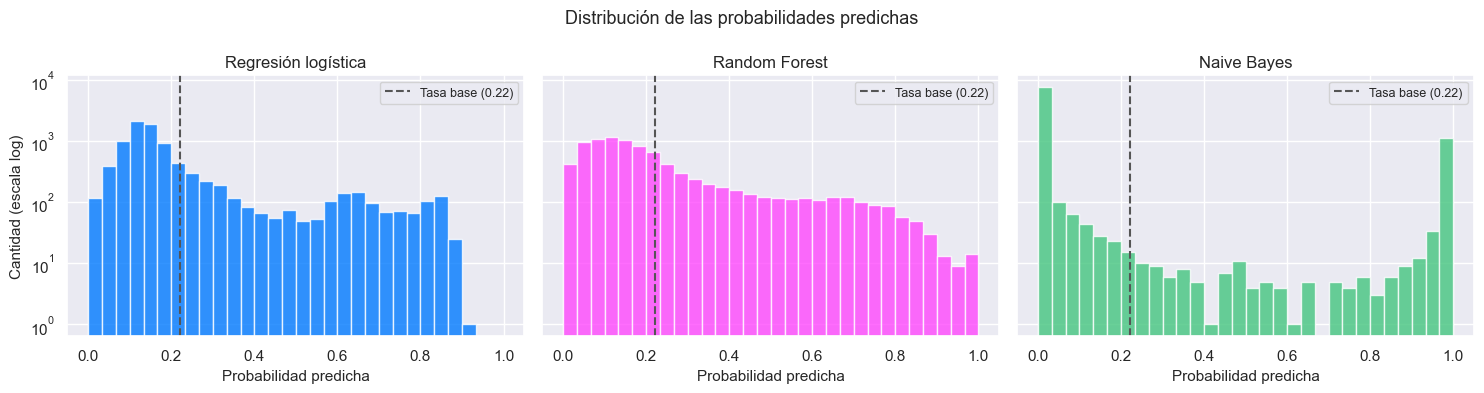

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
colores = [AZUL, MAGENTA, VERDE]

for ax, (nombre, p), color in zip(axes, probs.items(), colores):
    ax.hist(p, bins=30, range=(0, 1), color=color, alpha=0.8)
    ax.axvline(tasa_base, color=GRIS, linestyle="--", lw=1.5,
               label=f"Tasa base ({tasa_base:.2f})")
    ax.set_title(nombre, fontsize=12)
    ax.set_xlabel("Probabilidad predicha", fontsize=11)
    ax.set_yscale("log")
    ax.legend(fontsize=9)

axes[0].set_ylabel("Cantidad (escala log)", fontsize=11)
plt.suptitle("Distribución de las probabilidades predichas", fontsize=13)
plt.tight_layout()
plt.show()

Acá aparece lo primero interesante: **modelos con AUC parecido producen distribuciones de probabilidad muy
distintas**.

La regresión logística y el Random Forest reparten sus predicciones de forma razonable alrededor de la tasa base.
**Naive Bayes**, en cambio, acumula casi todo en los extremos: o $0$ o $1$, con muy poco en el medio.

La causa la vimos en el EDA. Naive Bayes asume que las features son **condicionalmente independientes** dada la
clase, y en este dataset esa hipótesis se rompe de forma masiva: los seis `BILL_AMT*` tienen una correlación media
de $0.89$ entre sí (y de $0.95$ entre meses consecutivos). No son seis evidencias distintas sobre el cliente, son
**una sola señal medida seis veces**. Al multiplicar sus verosimilitudes como si fueran independientes, el modelo
cuenta seis veces la misma evidencia y su confianza se dispara.

El AUC no vio nada de esto, porque **solo depende del orden de los scores, no de sus valores**.

## Midiendo la calibración

### La curva de calibración (*reliability diagram*)

La construcción es simple:

1. Dividimos las predicciones en $M$ intervalos (bins).
2. En el eje X ponemos el promedio de la probabilidad **predicha** en cada bin.
3. En el eje Y ponemos la proporción **real** de positivos en ese bin.

Si el modelo está calibrado, los puntos caen sobre la diagonal $y = x$.

Armamos una función que grafique esto junto con el histograma de predicciones. El histograma no es decorativo: sin
él no hay forma de distinguir una desviación real de un bin con cuatro observaciones.

In [13]:
from sklearn.calibration import calibration_curve


def plot_calibracion(y_true, probs_dict, colores,
                     titulo="Curva de calibración", n_bins=10):
    fig, (ax, ax_hist) = plt.subplots(
        2, 1, figsize=(8, 7.5), sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.07})

    ax.plot([0, 1], [0, 1], "--", lw=1.8, color=GRIS, label="Calibración perfecta")

    for (nombre, p), color in zip(probs_dict.items(), colores):
        frac_pos, mean_pred = calibration_curve(y_true, p, n_bins=n_bins)
        ax.plot(mean_pred, frac_pos, "o-", lw=2.2, markersize=7, color=color,
                markeredgecolor="white", markeredgewidth=1.2, label=nombre)
        ax_hist.hist(p, bins=np.linspace(0, 1, 41), color=color, alpha=0.6, lw=0)

    ax.set_ylabel("Frecuencia real observada", fontsize=11)
    ax.set_title(titulo, fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=10, loc="upper left")

    ax_hist.set_xlabel("Probabilidad predicha", fontsize=11)
    ax_hist.set_ylabel("Cantidad", fontsize=11)
    ax_hist.set_yscale("log")

    plt.show()

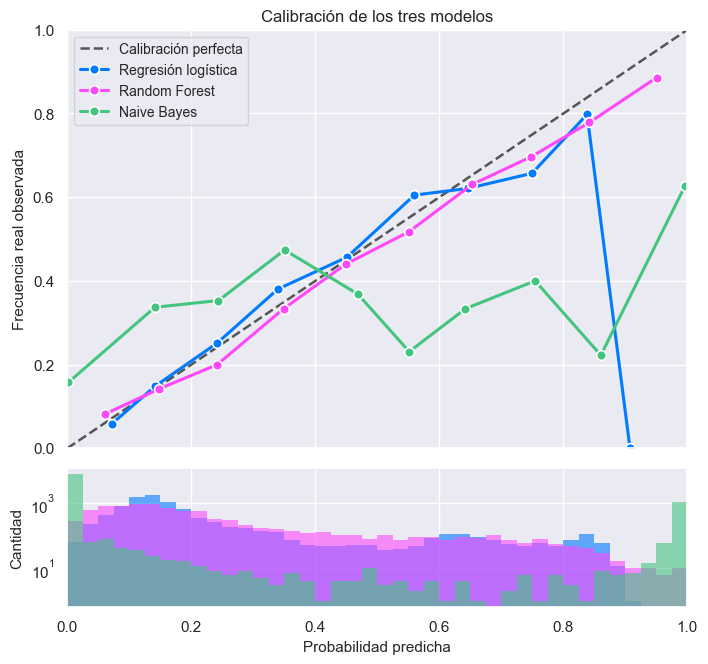

In [14]:
plot_calibracion(y_test, probs, [AZUL, MAGENTA, VERDE],
                 "Calibración de los tres modelos")

Ahora sí se ve lo que el AUC escondía. **Naive Bayes** es un desastre: en el rango alto de scores la frecuencia real
está muy por debajo de lo prometido, o sea que **sobreestima** el riesgo de forma sistemática. Los otros dos quedan
razonablemente cerca de la diagonal.

Regla de lectura: **curva por debajo de la diagonal → el modelo sobreestima; por encima → subestima.**

### Las métricas

La curva es un diagnóstico visual. Para comparar necesitamos números.

- **Brier Score**: error cuadrático medio entre la probabilidad predicha y el resultado observado,
  $\frac{1}{N}\sum (p_i - y_i)^2$.
- **Log loss**: castiga mucho más fuerte los errores confiados.
- **ECE** (*Expected Calibration Error*): promedio de las distancias verticales a la diagonal, ponderado por cuántas
  observaciones caen en cada bin. Es la única de las tres que mide **solo** calibración.

Scikit-learn no trae ECE, así que la implementamos.

In [15]:
def expected_calibration_error(y_true, probs, n_bins=10):
    """Distancia media a la diagonal, ponderada por el tamaño de cada bin."""
    y_true = np.asarray(y_true)
    bordes = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(probs, bordes[1:-1]), 0, n_bins - 1)

    ece = 0.0
    for b in range(n_bins):
        mask = idx == b
        if not mask.any():
            continue
        ece += mask.sum() / len(probs) * abs(y_true[mask].mean() - probs[mask].mean())
    return ece

In [16]:
from sklearn.metrics import brier_score_loss, log_loss


def resumen_calibracion(y_true, probs_dict):
    return pd.DataFrame({
        nombre: {
            "AUC": roc_auc_score(y_true, p),
            "Accuracy": accuracy_score(y_true, p >= 0.5),  # noqa: PLR2004
            "Brier": brier_score_loss(y_true, p),
            "LogLoss": log_loss(y_true, p),
            "ECE": expected_calibration_error(y_true, p),
        }
        for nombre, p in probs_dict.items()
    }).T


resumen_calibracion(y_test, probs).round(4)

,AUC,Accuracy,Brier,LogLoss,ECE
Regresión logística,0.7628,0.8177,0.1385,0.4415,0.0143
Random Forest,0.7627,0.8130,0.1388,0.4420,0.0193
Naive Bayes,0.7459,0.8081,0.1864,2.7795,0.1847


La **regresión logística es la mejor calibrada** de las tres, con un ECE de $0.014$. No es casualidad: es el único
modelo que optimiza directamente la probabilidad, así que su función de costo **es** producir buenas probabilidades.

Vale la pena detenerse acá, porque esto depende de haber preparado bien las features. Si hubiéramos tratado a las
`PAY_*` como numéricas —que es lo que uno hace si no mira el EDA— la logística habría quedado con un AUC de $0.715$
y un ECE de $0.049$: **peor calibrada que el Random Forest**. Su garantía de calibración vale solo si el *log-odds*
real es lineal en las features, y con las `PAY_*` sin codificar no lo es, porque su efecto es un escalón.

> Una parte de la descalibración se arregla con **mejores features**, no con un calibrador. Conviene descartar la
> mala especificación antes de salir a calibrar.

El **Random Forest** queda muy cerca ($0.019$), y **Naive Bayes** es un desastre ($0.185$).

Sobre el **Brier Score**, un detalle importante: no es una métrica pura de calibración. Se descompone en tres
términos,

$$\text{BS} = \underbrace{\text{Confiabilidad}}_{\text{calibración}} - \underbrace{\text{Resolución}}_{\text{discriminación}} + \underbrace{\text{Incertidumbre}}_{\bar{y}(1-\bar{y})}$$

así que mezcla calibración con discriminación. Por eso **no conviene comparar el Brier entre modelos distintos**,
pero **sí** es válido comparar el mismo modelo antes y después de calibrar: ahí la resolución queda fija y toda la
mejora observada es calibración.

El término de incertidumbre depende solo del dataset, y nos da un piso de referencia muy útil:

In [17]:
piso = tasa_base * (1 - tasa_base)
print(f"Brier del modelo que predice siempre la tasa base: {piso:.4f}")

Brier del modelo que predice siempre la tasa base: 0.1723


Cualquier modelo con Brier por encima de $0.1723$ es **peor que no tener modelo**. Y si volvemos a la tabla,
Naive Bayes tiene un Brier de $0.2213$: está justamente en esa situación. A pesar de tener un AUC de $0.73$ —o sea,
de ordenar razonablemente bien— sus probabilidades son tan malas que conviene más predecir $0.22$ para todo el mundo.

Es el análogo exacto del "accuracy del $78\%$" que se consigue prediciendo siempre la clase mayoritaria.

## Calibrar: primero, la forma **incorrecta**

Calibrar significa aprender una función $f_{calib}$ que transforme el score del modelo en una probabilidad
confiable. Esa función se entrena con datos, y la pregunta crítica es **cuáles**.

El error más común es usar los mismos datos con los que se entrenó el modelo base. Para entender por qué falla,
grafiquemos la curva de calibración del Random Forest sobre *train* y sobre *test*, por separado.

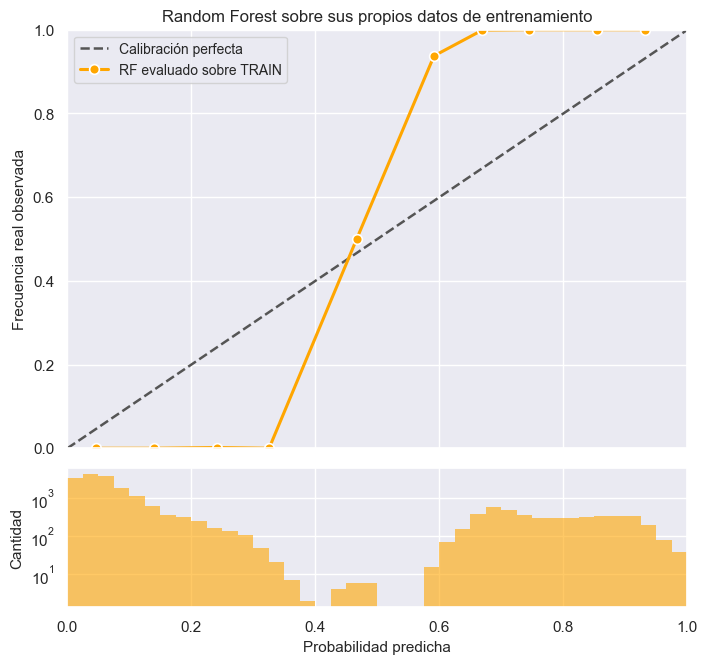

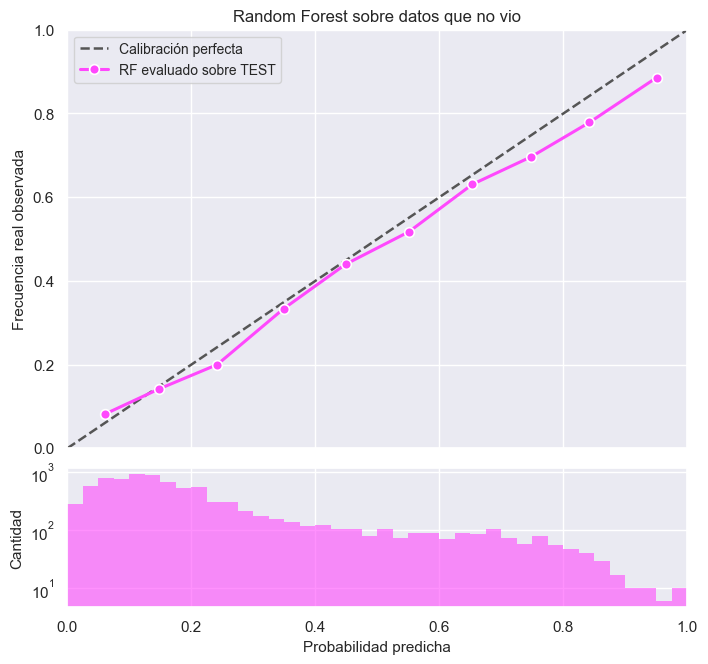

In [18]:
plot_calibracion(y_train, {"RF evaluado sobre TRAIN": rf.predict_proba(X_train)[:, 1]},
                 [NARANJA], "Random Forest sobre sus propios datos de entrenamiento")

plot_calibracion(y_test, {"RF evaluado sobre TEST": probs["Random Forest"]},
                 [MAGENTA], "Random Forest sobre datos que no vio")

Son dos modelos distintos, y sin embargo es el mismo modelo.

Sobre **train**, la curva es prácticamente un escalón: todo lo que el bosque puntúa por debajo de $\approx 0.45$
tiene frecuencia real $0$, y todo lo que puntúa por encima de $\approx 0.65$ tiene frecuencia real $1$. Es lo
esperable de árboles crecidos a fondo: memorizaron las etiquetas, así que sobre esos datos aciertan casi siempre.

Sobre **test**, la misma curva sigue la diagonal de forma bastante razonable.

Ahora se ve el problema. Si ajustamos el calibrador sobre train, aprende la regla *"cuando el modelo dice 0.65, la
realidad es 1.0"*. Aplicada a datos nuevos, donde 0.65 significa 0.63, esa regla infla las probabilidades de forma
brutal. Comprobémoslo.

In [19]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

# FrozenEstimator evita que se reentrene el modelo base: solo se ajusta el calibrador
rf_mal = CalibratedClassifierCV(FrozenEstimator(rf), method="isotonic")
rf_mal.fit(X_train, y_train)   # <-- los MISMOS datos con los que se entrenó rf

resumen_calibracion(y_test, {
    "RF sin calibrar": probs["Random Forest"],
    "RF calibrado sobre train (MAL)": rf_mal.predict_proba(X_test)[:, 1],
}).round(4)

,AUC,Accuracy,Brier,LogLoss,ECE
RF sin calibrar,0.7627,0.8130,0.1388,0.4420,0.0193
RF calibrado sobre train (MAL),0.7179,0.8104,0.1705,4.4657,0.1539


Empeoró en todo: el ECE se multiplicó por seis, el Brier subió por encima del piso de $0.1723$ y hasta el AUC cayó.

> **No es un error que degrade un poco el resultado: es un error que empeora activamente el modelo.**

Un matiz que conviene tener presente: la gravedad del problema es proporcional a **cuánto sobreajusta el modelo
base**. Un Random Forest de árboles completos memoriza, y por eso el desastre es tan visible. Un modelo de alto
sesgo como Naive Bayes casi no memoriza, y calibrarlo sobre train da un resultado casi idéntico al correcto. Pero
como en general no sabemos de antemano cuánto sobreajusta nuestro modelo, la regla se aplica siempre.

## Forma correcta 1: conjunto de calibración separado

La opción más simple es partir los datos en tres: entrenamiento, calibración y testeo.

```
[------ train ------][--- calibración ---][--- test ---]
   entrena el modelo    entrena f_calib     evalúa todo
```

Como el modelo base queda fijo, esta variante también nos sirve para verificar una propiedad importante de la
calibración.

In [20]:
# Partimos el train original en dos: uno para el modelo, otro para el calibrador
X_base, X_calib, y_base, y_calib = train_test_split(
    X_train, y_train, test_size=0.3, random_state=42, stratify=y_train)

print(f"Modelo base: {X_base.shape[0]} | Calibración: {X_calib.shape[0]} | "
      f"Test: {X_test.shape[0]}")

Modelo base: 14700 | Calibración: 6300 | Test: 9000


In [21]:
rf_base = make_pipeline(preprocesador(), bosque())
rf_base.fit(X_base, y_base)

# El modelo base queda congelado: solo se ajusta f_calib, con datos que no vio
rf_frozen = FrozenEstimator(rf_base)
rf_ho_platt = CalibratedClassifierCV(rf_frozen, method="sigmoid").fit(X_calib, y_calib)
rf_ho_iso = CalibratedClassifierCV(rf_frozen, method="isotonic").fit(X_calib, y_calib)

probs_ho = {
    "RF base (sin calibrar)": rf_base.predict_proba(X_test)[:, 1],
    "RF + Platt": rf_ho_platt.predict_proba(X_test)[:, 1],
    "RF + Isotónica": rf_ho_iso.predict_proba(X_test)[:, 1],
}

resumen_calibracion(y_test, probs_ho).round(4)

,AUC,Accuracy,Brier,LogLoss,ECE
RF base (sin calibrar),0.7618,0.8130,0.1394,0.4435,0.0232
RF + Platt,0.7618,0.8126,0.1391,0.4418,0.0159
RF + Isotónica,0.7604,0.8138,0.1394,0.4491,0.0099


El ECE bajó con los dos métodos, y la isotónica funcionó mejor que Platt.

### ¿Qué le pasó al ranking?

Miremos la columna del AUC con más decimales.

In [22]:
for nombre, p in probs_ho.items():
    acc = accuracy_score(y_test, p >= 0.5)  # noqa: PLR2004
    print(f"{nombre:<24} AUC = {roc_auc_score(y_test, p):.8f}   Accuracy = {acc:.4f}")

RF base (sin calibrar)   AUC = 0.76175129   Accuracy = 0.8130
RF + Platt               AUC = 0.76175129   Accuracy = 0.8126
RF + Isotónica           AUC = 0.76040456   Accuracy = 0.8138


Comparemos las dos magnitudes del cambio:

- Con **Platt**, el AUC es **exactamente el mismo**, hasta el último decimal que imprimimos. Platt Scaling aplica
  una sigmoide, que es estrictamente creciente, así que **no puede alterar el orden de las instancias**. Y como el
  AUC solo depende del orden, no se mueve ni un dígito.
- Con la **isotónica**, el AUC baja en el **tercer decimal**. También es monótona, pero *no decreciente*: al
  aplastar tramos enteros de scores en un mismo valor, genera **empates** entre observaciones que antes estaban
  ordenadas, y esos empates sí degradan el AUC de forma real (aunque pequeña).

El **accuracy sí cambia**, y conviene entender por qué: aunque el orden se preserve, la calibración **mueve los
scores respecto del umbral**. Un caso que valía $0.55$ puede quedar en $0.45$, cruzar el $0.5$ y cambiar de clase
predicha.

> Se preserva el **ranking**, no las **decisiones a umbral fijo**.

## Forma correcta 2: validación cruzada

Separar un conjunto de calibración cuesta datos. `CalibratedClassifierCV` con `cv=5` evita ese costo:

1. Para cada fold, entrena el modelo base con los otros $k-1$ folds y predice sobre el fold que quedó afuera.
2. Como cada observación fue predicha por un modelo que **no la vio**, quedan scores fuera de muestra para todo el
   conjunto de entrenamiento.
3. Ajusta $f_{calib}$ sobre esos scores.

Ahora se pasa el modelo **sin entrenar**: la clase se encarga de todo. Apliquémoslo al caso más grave, Naive Bayes.

In [23]:
gnb_platt = CalibratedClassifierCV(
    make_pipeline(preprocesador(), GaussianNB()), method="sigmoid", cv=5)
gnb_iso = CalibratedClassifierCV(
    make_pipeline(preprocesador(), GaussianNB()), method="isotonic", cv=5)

gnb_platt.fit(X_train, y_train)
gnb_iso.fit(X_train, y_train)

probs_gnb = {
    "NB sin calibrar": probs["Naive Bayes"],
    "NB + Platt": gnb_platt.predict_proba(X_test)[:, 1],
    "NB + Isotónica": gnb_iso.predict_proba(X_test)[:, 1],
}

resumen_calibracion(y_test, probs_gnb).round(4)

,AUC,Accuracy,Brier,LogLoss,ECE
NB sin calibrar,0.7459,0.8081,0.1864,2.7795,0.1847
NB + Platt,0.7453,0.8094,0.1455,0.4609,0.0353
NB + Isotónica,0.7467,0.8107,0.1426,0.4512,0.0142


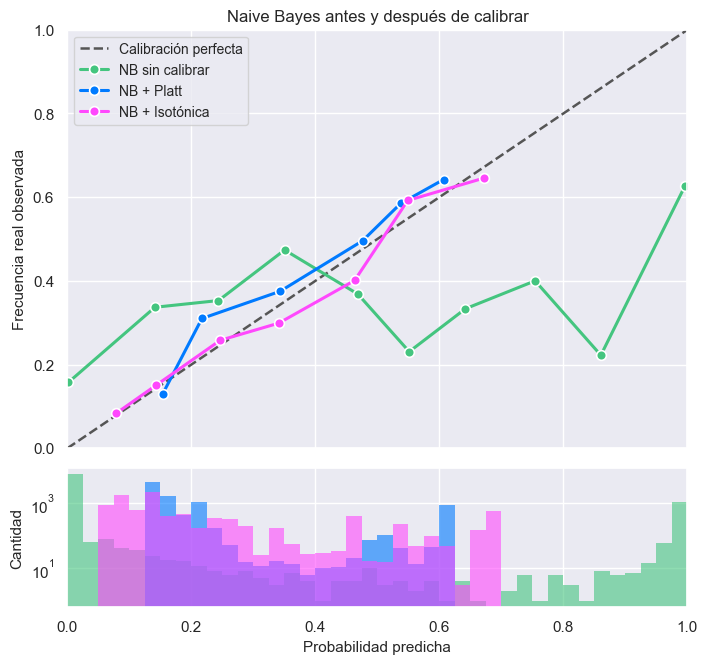

In [24]:
plot_calibracion(y_test, probs_gnb, [VERDE, AZUL, MAGENTA],
                 "Naive Bayes antes y después de calibrar")

Acá la mejora es espectacular: el ECE cayó de $0.22$ a menos de $0.02$ y el Brier pasó de $0.2213$ —peor que el
piso— a $0.145$, holgadamente por debajo. El modelo pasó de ser inservible como estimador de probabilidad a ser
perfectamente usable.

Y lo más importante: **el AUC casi no se movió**. No mejoramos la capacidad de discriminar del modelo; solamente
arreglamos la escala de sus números.

Una diferencia respecto del caso anterior: con `cv=5`, `CalibratedClassifierCV` entrena **cinco** modelos base y
promedia sus predicciones calibradas. Es decir, el resultado no es solo "el mismo modelo mejor calibrado", sino
además un pequeño ensamble. Por eso acá el AUC sí puede moverse un poco, a diferencia del caso *hold-out*.

## La función de calibración aprendida

Podemos hacer visible qué está haciendo cada método: graficamos el score original contra el score calibrado.

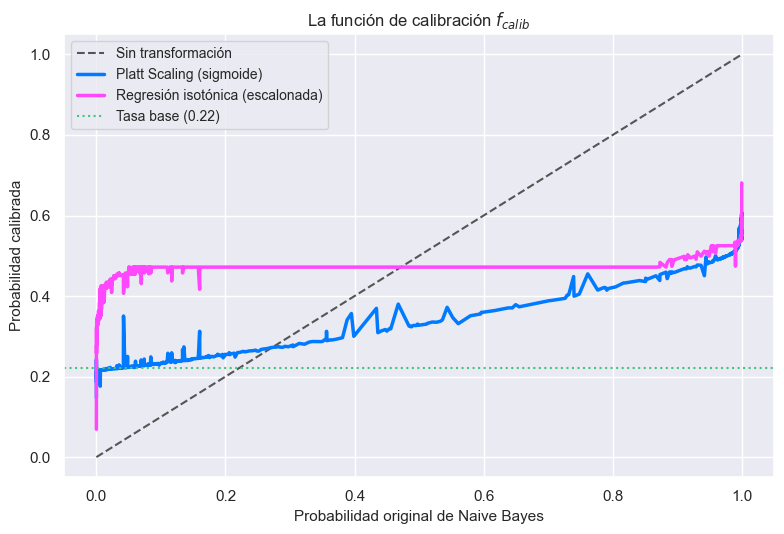

In [25]:
orden = np.argsort(probs["Naive Bayes"])
p_orig = probs["Naive Bayes"][orden]

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.plot([0, 1], [0, 1], "--", lw=1.5, color=GRIS, label="Sin transformación")
ax.plot(p_orig, probs_gnb["NB + Platt"][orden], lw=2.5, color=AZUL,
        label="Platt Scaling (sigmoide)")
ax.plot(p_orig, probs_gnb["NB + Isotónica"][orden], lw=2.5, color=MAGENTA,
        label="Regresión isotónica (escalonada)")
ax.axhline(tasa_base, color=VERDE, linestyle=":", lw=1.5,
           label=f"Tasa base ({tasa_base:.2f})")

ax.set_xlabel("Probabilidad original de Naive Bayes", fontsize=11)
ax.set_ylabel("Probabilidad calibrada", fontsize=11)
ax.set_title("La función de calibración $f_{calib}$", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

El gráfico muestra de un vistazo la diferencia entre los dos métodos:

- **Platt** produce una curva **suave**. Solo tiene dos parámetros ($A$ y $B$), así que no puede hacer otra cosa que
  una sigmoide. Es rígido, pero justamente por eso es muy difícil de sobreajustar.
- La **isotónica** produce una **escalera**. No asume ninguna forma funcional: solo exige que la función no decrezca.
  Es mucho más flexible, y por eso necesita bastantes más datos: con pocas observaciones, los escalones se ajustan
  al ruido.

Ambas son monótonas crecientes, que es la razón por la que el ranking se preserva.

También se ve la magnitud de la corrección: el $0.99$ que emitía Naive Bayes termina convertido en algo mucho más
moderado. La función está aplastando una confianza que no estaba justificada.

## Un caso que aparece siempre: el remuestreo

Hay una causa de descalibración que no depende del algoritmo y que en la práctica es de las más frecuentes:
**haber alterado la proporción de clases durante el entrenamiento**.

Nuestro dataset tiene $22\%$ de positivos. Hagamos lo que se hace habitualmente para mejorar el recall de la clase
minoritaria: *undersampling* de la mayoritaria, hasta llegar a un 50/50.

Vamos a remuestrear a partir de `X_base`, de modo que el conjunto de calibración siga siendo material que el modelo
no vio, y —lo más importante para lo que queremos mostrar— **conserve la proporción real de clases**.

In [26]:
rng = np.random.default_rng(42)

idx_pos = np.flatnonzero(y_base.to_numpy() == 1)
idx_neg = np.flatnonzero(y_base.to_numpy() == 0)
idx_neg_sub = rng.choice(idx_neg, size=len(idx_pos), replace=False)

idx_bal = np.concatenate([idx_pos, idx_neg_sub])
X_bal, y_bal = X_base.iloc[idx_bal], y_base.iloc[idx_bal]

print(f"X_base original:     {len(y_base):>5} obs, {y_base.mean():.2%} de positivos")
print(f"X_base remuestreado: {len(y_bal):>5} obs, {y_bal.mean():.2%} de positivos")
print(f"X_calib (intacto):   {len(y_calib):>5} obs, {y_calib.mean():.2%} de positivos")

X_base original:     14700 obs, 22.12% de positivos
X_base remuestreado:  6504 obs, 50.00% de positivos
X_calib (intacto):    6300 obs, 22.11% de positivos


In [27]:
rf_under = make_pipeline(preprocesador(), bosque())
rf_under.fit(X_bal, y_bal)

probs_under = rf_under.predict_proba(X_test)[:, 1]

print(f"Tasa base real en test:              {y_test.mean():.4f}")
p_orig_ho = probs_ho["RF base (sin calibrar)"]
print(f"Media de p del modelo original:      {p_orig_ho.mean():.4f}")
print(f"Media de p del modelo remuestreado:  {probs_under.mean():.4f}")

Tasa base real en test:              0.2212
Media de p del modelo original:      0.2301
Media de p del modelo remuestreado:  0.4366


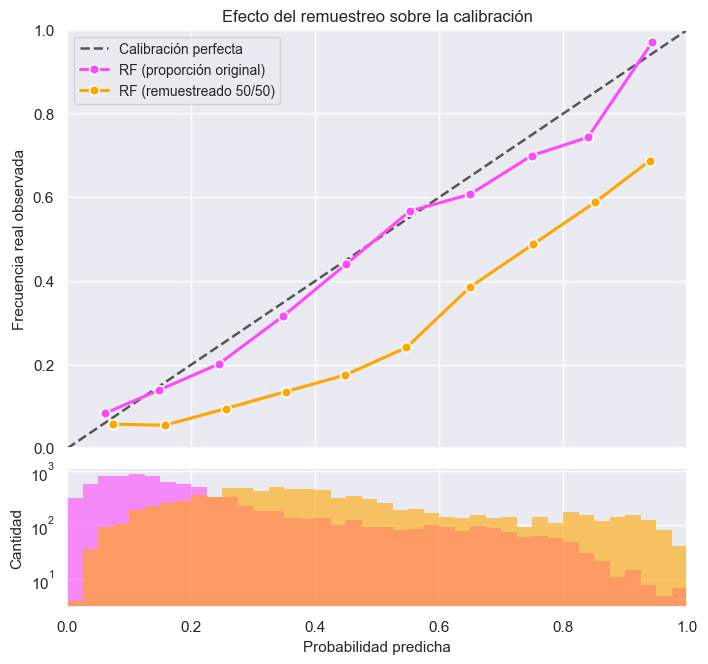

In [28]:
plot_calibracion(y_test, {
    "RF (proporción original)": probs_ho["RF base (sin calibrar)"],
    "RF (remuestreado 50/50)": probs_under,
}, [MAGENTA, NARANJA], "Efecto del remuestreo sobre la calibración")

El modelo remuestreado quedó **muy por debajo de la diagonal**: sobreestima el riesgo de default en todo el rango, y
su probabilidad promedio se corrió bastante por encima de la tasa base real.

Tiene sentido: al descartar negativos, el modelo aprende a estimar probabilidades sobre una distribución donde los
positivos pesan el $50\%$ y no el $22\%$. Lo mismo ocurre con *oversampling* y con SMOTE.

**Esto no es un defecto del método de balanceo** —esas técnicas mejoran la discriminación y por eso las usamos—. Es
un efecto colateral esperable, y la respuesta correcta es **calibrar después, sobre datos con la proporción real de
clases**. Que es justamente lo que tenemos en el conjunto de calibración.

In [29]:
rf_under_cal = CalibratedClassifierCV(
    FrozenEstimator(rf_under), method="isotonic")
rf_under_cal.fit(X_calib, y_calib)

resumen_calibracion(y_test, {
    "RF remuestreado (sin calibrar)": probs_under,
    "RF remuestreado + Isotónica": rf_under_cal.predict_proba(X_test)[:, 1],
}).round(4)

,AUC,Accuracy,Brier,LogLoss,ECE
RF remuestreado (sin calibrar),0.7657,0.7429,0.1909,0.5750,0.2154
RF remuestreado + Isotónica,0.7651,0.8070,0.1400,0.4568,0.0136


La calibración recupera el ECE y el Brier sin tocar el AUC: la discriminación que aportó el remuestreo se conserva,
y las probabilidades vuelven a ser interpretables.

## Cierre

Lo que vimos en esta notebook:

1. **Discriminación y calibración son propiedades independientes.** Tres modelos con AUC parecido produjeron
   probabilidades de calidad muy distinta.
2. **El AUC es ciego a los valores**: solo mira el orden. Para evaluar las probabilidades hay que mirar la curva de
   calibración y el ECE.
3. **"La regresión logística viene calibrada" es cierto bajo condiciones.** Acá el Random Forest quedó mejor
   calibrado que ella, porque el *log-odds* real no es lineal. Siempre hay que verificar.
4. **El Brier Score mezcla** calibración y discriminación, y tiene un piso conocido, $\bar{y}(1-\bar{y})$. Sirve
   para comparar un modelo consigo mismo antes y después de calibrar, no para comparar modelos distintos.
5. **Calibrar sobre los datos de entrenamiento del modelo base lo empeora.** Hay que usar un conjunto separado o
   validación cruzada.
6. **Platt** es rígido y seguro; la **isotónica** es flexible y necesita más datos. Ambas preservan el ranking
   (Platt de forma exacta), pero pueden cambiar las decisiones a umbral fijo.
7. **Remuestrear descalibra el modelo.** Es esperable, y se corrige calibrando después con la proporción real de
   clases.

---

Una advertencia para cerrar. Todo lo anterior salió limpio porque teníamos **30.000 observaciones**: las curvas eran
suaves y las diferencias entre métodos, legibles. Con un dataset chico —que es la situación mucho más habitual— la
mayoría de estas conclusiones deja de poder sacarse de una sola partición. Eso es lo que exploramos en la notebook
`2 - Calibracion con pocos datos`.